<a href="https://colab.research.google.com/github/dbaglodi/CREPE-YOLO/blob/main/CREPE_YOLO_eval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
## 0 · Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ── Restore previous outputs from Google Drive ────────────────────────────────
# Safe to run even if Drive folder doesn't exist yet — it just prints a message.
import shutil
from pathlib import Path

DRIVE_OUT     = Path('/content/drive/MyDrive/DL Project/crepe_yolo_outputs')
WORK_DIR      = Path('/content/crepe_yolo')
PROCESSED_DIR = WORK_DIR / 'processed' / 'itm_flute'
SPLIT_DIR     = WORK_DIR / 'configs'
PRED_DIR      = WORK_DIR / 'predictions'
EVAL_DIR      = WORK_DIR / 'evaluation'

if not DRIVE_OUT.exists():
    print('No previous outputs found on Drive — starting fresh.')
    print(f'  (Expected: {DRIVE_OUT})')
else:
    print(f'Found previous outputs at {DRIVE_OUT}')
    print('Restoring...')
    restored = []

    # configs/ -> SPLIT_DIR
    src = DRIVE_OUT / 'configs'
    if src.exists():
        shutil.copytree(src, SPLIT_DIR, dirs_exist_ok=True)
        restored.append(f'configs/  ({len(list(src.rglob("*")))} files)')

    # predictions/ -> PRED_DIR
    src = DRIVE_OUT / 'predictions'
    if src.exists():
        shutil.copytree(src, PRED_DIR, dirs_exist_ok=True)
        restored.append(f'predictions/  ({len(list(src.rglob("*.json")))} JSONs)')

    # evaluation/ -> EVAL_DIR
    src = DRIVE_OUT / 'evaluation'
    if src.exists():
        shutil.copytree(src, EVAL_DIR, dirs_exist_ok=True)
        restored.append(f'evaluation/  ({len(list(src.rglob("*")))} files)')

    # processed/*/notes.json -> PROCESSED_DIR (audio_16k.wav is not on Drive)
    src = DRIVE_OUT / 'processed'
    n_notes = 0
    if src.exists():
        for notes_src in src.rglob('notes.json'):
            dst = PROCESSED_DIR / notes_src.relative_to(src)
            dst.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(notes_src, dst)
            n_notes += 1
        restored.append(f'processed/  ({n_notes} notes.json files)')

    for item in restored:
        print(f'  OK  {item}')

    # Report what can be skipped
    print()
    print('Steps you can skip (outputs already present):')
    skip_map = [
        ('Cell 4 — Generate splits',  SPLIT_DIR / 'itm_flute_splits.json'),
        ('Cell 5 — Preprocess',       PROCESSED_DIR),
        ('Cell 7 — pYIN baseline',    PRED_DIR / 'pyin'),
        ('Cell 8 — CREPE Notes',      PRED_DIR / 'crepe_notes'),
        ('Cell 9 — MT3',              PRED_DIR / 'mt3'),
        ('Cell 10 — Evaluate',        EVAL_DIR / 'results.json'),
    ]
    any_skip = False
    for label, path in skip_map:
        if path.exists():
            n = len(list(path.rglob('*'))) if path.is_dir() else 1
            print(f'  SKIP  {label}  ({n} files)')
            any_skip = True
    if not any_skip:
        print('  (none — run all cells)')
    print()
    print('Note: Cell 5 will still re-run ffmpeg for any piece missing audio_16k.wav')
    print('      (audio is not saved to Drive). All other cells skip existing files.')

Found previous outputs at /content/drive/MyDrive/DL Project/crepe_yolo_outputs
Restoring...
  OK  configs/  (1 files)
  OK  predictions/  (194 JSONs)
  OK  evaluation/  (5 files)
  OK  processed/  (337 notes.json files)

Steps you can skip (outputs already present):
  SKIP  Cell 4 — Generate splits  (1 files)
  SKIP  Cell 5 — Preprocess  (675 files)
  SKIP  Cell 7 — pYIN baseline  (97 files)
  SKIP  Cell 8 — CREPE Notes  (97 files)
  SKIP  Cell 9 — MT3  (0 files)
  SKIP  Cell 10 — Evaluate  (1 files)

Note: Cell 5 will still re-run ffmpeg for any piece missing audio_16k.wav
      (audio is not saved to Drive). All other cells skip existing files.


---
## 1 · Install Dependencies

In [ ]:
# Required fix for madmom to run on Python 3.10+ in Colab
!pip install git+https://github.com/CPJKU/madmom@main

# Install the official CREPE Notes pipeline
!pip install crepe-notes[crepe]

# Core audio / ML / evaluation packages
!pip install -q crepe mir_eval librosa soundfile scipy matplotlib tqdm

# note_seq: MIDI I/O library used by MT3
!pip install -q note_seq==0.0.5

import crepe, mir_eval, librosa, soundfile, note_seq
print('All dependencies installed')
print(f'  crepe    {crepe.__version__}')
print(f'  mir_eval {mir_eval.__version__}')
print(f'  librosa  {librosa.__version__}')
print(f'  note_seq {note_seq.__version__}')

  Cloning https://github.com/CPJKU/madmom (to revision main) to /tmp/pip-req-build-sjfjy7ow
  Running command git clone --filter=blob:none --quiet https://github.com/CPJKU/madmom /tmp/pip-req-build-sjfjy7ow
  Resolved https://github.com/CPJKU/madmom to commit 27f032e8947204902c675e5e341a3faf5dc86dae
  Running command git submodule update --init --recursive -q
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.8 MB/s eta 0:00:00
  Created wheel for madmom: filename=madmom-0.17.dev0-cp312-cp312-linux_x86_64.whl size=26243897 sha256=9ec715a4d0437317044b315e457dd0b99e36680194dd6372387735358b0bb400
  Stored in directory: /tmp/pip-ephem-wheel-cache-3a5a2o2u/wheels/25/b1/02/2bf0906cd99271622261806fae445875ac9b510c1f722dbda2
Successfully built madmom
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 54.2

/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


All dependencies installed
  crepe    0.0.16
  mir_eval 0.8.2
  librosa  0.11.0
  note_seq 0.0.5


---
## 2 · Paths & Global Constants

In [ ]:
from pathlib import Path
import json, os, shutil, subprocess
import numpy as np

# ── Dataset (Google Drive layout) ────────────────────────────────────────────
#   GT-ITM-Flute-99/
#     audio/          <- .wav files
#     annotations/    <- .txt files
DATASET_ROOT = Path('/content/drive/MyDrive/DL Project/GT-ITM-Flute-99')
AUDIO_DIR    = DATASET_ROOT / 'audio'
ANNOT_DIR    = DATASET_ROOT / 'annotations'

# ── Colab working directories (local SSD) ────────────────────────────────────
WORK_DIR      = Path('/content/crepe_yolo')
PROCESSED_DIR = WORK_DIR / 'processed' / 'itm_flute'
SPLIT_DIR     = WORK_DIR / 'configs'
PRED_DIR      = WORK_DIR / 'predictions'
EVAL_DIR      = WORK_DIR / 'evaluation'

for d in [PROCESSED_DIR, SPLIT_DIR,
          PRED_DIR / 'pyin',
          PRED_DIR / 'crepe_notes',
          PRED_DIR / 'mt3',
          EVAL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Audio preprocessing target ───────────────────────────────────────────────
RESAMPLE_SR = 16000   # 16 kHz mono — CREPE's expected input

# ── mir_eval tolerances (matching CREPE Notes / MT3 papers) ──────────────────
ONSET_TOL    = 0.05   # 50 ms
OFFSET_RATIO = 0.20   # 20% of note duration
OFFSET_MIN   = 0.05   # 50 ms minimum
PITCH_TOL    = 0.5    # +/- 0.5 semitones

assert DATASET_ROOT.exists(), f'Dataset root not found: {DATASET_ROOT}'
assert AUDIO_DIR.exists(),    f'audio/ subfolder not found: {AUDIO_DIR}'
assert ANNOT_DIR.exists(),    f'annotations/ subfolder not found: {ANNOT_DIR}'

AUDIO_FILES = sorted(AUDIO_DIR.glob('*.wav'))
print(f'Dataset root   : {DATASET_ROOT}')
print(f'Audio files    : {len(AUDIO_FILES)}')
print(f'Annotation dir : {ANNOT_DIR}')
print(f'Working dir    : {WORK_DIR}')


Dataset root   : /content/drive/MyDrive/DL Project/GT-ITM-Flute-99
Audio files    : 99
Annotation dir : /content/drive/MyDrive/DL Project/GT-ITM-Flute-99/annotations
Working dir    : /content/crepe_yolo


---
## 3 · Inspect Dataset & Parse Annotations

In [ ]:
import soundfile as sf
from tqdm.notebook import tqdm

# Print a sample annotation to confirm the column format
sample_txts = sorted(ANNOT_DIR.glob('*.txt'))
if sample_txts:
    print(f'Sample annotation: {sample_txts[0].name}')
    print('Columns (tab-separated):')
    print('  [0]index  [1]source_file  [2]onset  [3]offset  [4]duration  [5]type  [6]note_name  [7]freq_hz')
    print('-' * 90)
    with open(sample_txts[0]) as fh:
        for idx, line in enumerate(fh):
            print(f'  {idx:3d}: {line.rstrip()}')
            if idx >= 9: print('  ...'); break
    print()

# Show the naming mismatch so it is clear what the prefix-stripping fixes
annot_example = sample_txts[0].stem if sample_txts else 'none'
audio_example = AUDIO_FILES[0].stem if AUDIO_FILES else 'none'
print(f'Audio stem example : {audio_example}')
print(f'Annot stem example : {annot_example}')
print('  => the izzy_GT_ prefix will be stripped so stems match')
print()

# ── Annotation parser ─────────────────────────────────────────────────────────
# Tab-separated 8-column format:
#   col 0: row index      col 1: source filename   col 2: onset (s)
#   col 3: offset (s)    col 4: duration (s)       col 5: note type (NOTE/ct/...)
#   col 6: note name (e.g. C#5, Bb4)               col 7: frequency (Hz)
#
# Annotation files are named  izzy_GT_<audio_stem>.txt
# Audio files are named        <audio_stem>.wav   (no prefix)
NOTE_MAP = {'C': 0, 'D': 2, 'E': 4, 'F': 5, 'G': 7, 'A': 9, 'B': 11}

def note_name_to_midi(name):
    name = name.strip()
    i = len(name) - 1
    while i >= 0 and (name[i].isdigit() or name[i] == '-'):
        i -= 1
    note_part  = name[:i+1]
    octave_str = name[i+1:]
    octave     = int(octave_str) if octave_str else 4
    semitone   = NOTE_MAP[note_part[0].upper()]
    if '#' in note_part: semitone += 1
    elif 'b' in note_part: semitone -= 1
    return 12 * (octave + 1) + semitone

def parse_annotation(path):
    """Parse ITM-Flute-99 tab-separated annotation file.
    Returns list of {onset, offset, pitch_midi}."""
    notes = []
    with open(path) as fh:
        for line in fh:
            line = line.strip()
            if not line or line.startswith('#'): continue
            parts = line.split('\t')         # tab-separated
            if len(parts) < 7: continue
            try:
                onset  = float(parts[2])     # col 2: onset time
                offset = float(parts[3])     # col 3: offset time
                p_raw  = parts[6].strip()    # col 6: note name
            except (ValueError, IndexError):
                continue
            try:
                pitch_midi = note_name_to_midi(p_raw)
            except Exception:
                continue  # skip rows with unparseable pitch (e.g. silence markers)
            notes.append({'onset': onset, 'offset': offset, 'pitch_midi': pitch_midi})
    return notes

# Build a lookup: audio_stem -> annotation Path
# Strip the 'izzy_GT_' prefix from annotation filenames to get the matching audio stem
_all_annot   = list(ANNOT_DIR.glob('*.txt'))
_annot_lookup = {}
for p in _all_annot:
    key = p.stem
    for prefix in ['izzy_GT_', 'GT_', 'izzy_']:
        if key.startswith(prefix):
            key = key[len(prefix):]
            break
    _annot_lookup[key] = p

def find_annotation(stem):
    if stem in _annot_lookup:
        return _annot_lookup[stem]
    # Fallback: substring search for any unexpected prefix variant
    for p in _all_annot:
        if p.stem.endswith(stem):
            return p
    return None

print(f'Annotation files found : {len(_all_annot)}')
print(f'Lookup table size      : {len(_annot_lookup)}')
if _annot_lookup:
    k0 = next(iter(_annot_lookup))
    print(f'Example: "{k0}" -> {_annot_lookup[k0].name}')

# ── Build dataset_info list ───────────────────────────────────────────────────
dataset_info, missing = [], []
for wav in tqdm(AUDIO_FILES, desc='Scanning'):
    annot = find_annotation(wav.stem)
    if annot is None:
        missing.append(wav.stem); continue
    try:
        info  = sf.info(str(wav))
        notes = parse_annotation(annot)
        dataset_info.append({
            'stem':       wav.stem,
            'wav_path':   wav,
            'annot_path': annot,
            'duration':   info.duration,
            'sr':         info.samplerate,
            'n_notes':    len(notes),
        })
    except Exception as e:
        print(f'  [WARN] {wav.stem}: {e}')

total_dur   = sum(d['duration'] for d in dataset_info)
total_notes = sum(d['n_notes']  for d in dataset_info)
print(f'\n{"="*50}')
print( '  ITM-Flute-99 Dataset Summary')
print(f'{"="*50}')
print(f'  Pieces with audio+annotation : {len(dataset_info)}')
print(f'  Missing annotations          : {len(missing)}')
if missing: print(f'    -> {missing[:5]}')
if dataset_info:
    print(f'  Total audio duration         : {total_dur/60:.1f} min')
    print(f'  Total annotated notes        : {total_notes}')
    print(f'  Avg notes / piece            : {total_notes/len(dataset_info):.0f}')
    print(f'  Sample rates found           : {set(d["sr"] for d in dataset_info)}')
else:
    print('  No pieces loaded - check annotation prefix logic above.')


Sample annotation: izzy_GT_10_Bra_FirstMay_Tk4Tu1R2_TheDancerAtTheFair.txt
Columns (tab-separated):
  [0]index  [1]source_file  [2]onset  [3]offset  [4]duration  [5]type  [6]note_name  [7]freq_hz
------------------------------------------------------------------------------------------
    0: 1	Bra_FirstMay_Tk4Tu1R2_TheDancerAtTheFair.txt	0.017415	0.22059	0.20317	NOTE	C#5	553.069
    1: 2	Bra_FirstMay_Tk4Tu1R2_TheDancerAtTheFair.txt	0.22059	0.3483	0.12771	NOTE	Bb4	468.466
    2: 3	Bra_FirstMay_Tk4Tu1R2_TheDancerAtTheFair.txt	0.3483	0.55147	0.20317	NOTE	C5	521.627
    3: 4	Bra_FirstMay_Tk4Tu1R2_TheDancerAtTheFair.txt	0.55147	0.68934	0.13787	NOTE	Eb5	617.662
    4: 5	Bra_FirstMay_Tk4Tu1R2_TheDancerAtTheFair.txt	0.68934	0.86494	0.1756	NOTE	C#5	551.608
    5: 6	Bra_FirstMay_Tk4Tu1R2_TheDancerAtTheFair.txt	0.86494	1.0304	0.16544	NOTE	Bb4	467.015
    6: 7	Bra_FirstMay_Tk4Tu1R2_TheDancerAtTheFair.txt	1.0304	1.2074	0.17703	NOTE	C5	522.073
    7: 8	Bra_FirstMay_Tk4Tu1R2_TheDancerAtTheFair.txt	1

Scanning:   0%|          | 0/99 [00:00<?, ?it/s]


  ITM-Flute-99 Dataset Summary
  Pieces with audio+annotation : 97
  Missing annotations          : 2
    -> ['35_Mol_MattMolloy_Tk4Tu1R1_TheGold Ring', '64_Tan_FieldRecordings_Tk2Tu2R1_TheMaidBehindTheBar']
  Total audio duration         : 52.3 min
  Total annotated notes        : 21616
  Avg notes / piece            : 223
  Sample rates found           : {48000, 44100}


---
## 4 · Generate Dataset


In [ ]:
# ITM-Flute-99 is used entirely for evaluation/generalization testing,
# not for training. No train/test split is needed — all 99 pieces are
# evaluated. We save the piece list for reproducibility.
all_stems = [d['stem'] for d in dataset_info]

split_data = {
    'dataset':   'ITM-Flute-99',
    'reference': 'Kökuer et al. (2019)',
    'usage':     'Generalization evaluation only (no training). All pieces evaluated.',
    'all_pieces': all_stems,
    'n_pieces':  len(all_stems),
}
split_path = SPLIT_DIR / 'itm_flute_splits.json'
with open(split_path, 'w') as f:
    json.dump(split_data, f, indent=2)

print(f'Saved piece list ({len(all_stems)} pieces) -> {split_path}')

Saved piece list (97 pieces) -> /content/crepe_yolo/configs/itm_flute_splits.json


---
## 5 · Preprocess Audio & Clean Annotations


In [ ]:
import soundfile as sf

def midi_to_hz(m):    return 440.0 * (2 ** ((m - 69) / 12))

def clean_notes(raw, duration):
    """Remove malformed notes, sort by onset, clamp to audio length."""
    out = []
    for n in raw:
        on  = float(n.get('onset',  n.get('onset_time',  0)))
        off = float(n.get('offset', n.get('offset_time', 0)))
        pm  = n.get('pitch_midi', n.get('pitch'))
        if pm is None: continue
        pm = int(pm)
        if not (21 <= pm <= 108): continue   # outside piano/flute range
        if off <= on: continue               # zero or negative duration
        off = min(off, duration)             # clamp to audio length
        if off <= on: continue
        out.append({'onset': on, 'offset': off, 'pitch_midi': pm})
    return sorted(out, key=lambda x: x['onset'])

def resample_normalize(src, dst):
    """Resample to 16 kHz mono + EBU R128 loudness normalization."""
    r = subprocess.run([
        'ffmpeg', '-y', '-i', str(src),
        '-ac', '1', '-ar', str(RESAMPLE_SR),
        '-filter:a', 'loudnorm=I=-23:LRA=11:TP=-2',
        str(dst), '-loglevel', 'error'
    ], capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError(f'ffmpeg: {r.stderr[:200]}')

skipped = []
for entry in tqdm(dataset_info, desc='Preprocessing'):
    stem    = entry['stem']
    out_dir = PROCESSED_DIR / stem
    out_dir.mkdir(parents=True, exist_ok=True)
    wav_dst = out_dir / 'audio_16k.wav'
    try:
        if not wav_dst.exists():
            resample_normalize(entry['wav_path'], wav_dst)
        duration = sf.info(str(wav_dst)).duration
        raw      = parse_annotation(entry['annot_path'])
        notes    = clean_notes(raw, duration)
        with open(out_dir / 'notes.json', 'w') as f:
            json.dump(notes, f, indent=2)
    except Exception as e:
        print(f'  [ERROR] {stem}: {e}'); skipped.append(stem)

processed = [d['stem'] for d in dataset_info if d['stem'] not in skipped]
print(f'Preprocessed : {len(processed)} pieces  |  Skipped: {len(skipped)}')

# Quick sanity check
s0 = processed[0]
with open(PROCESSED_DIR / s0 / 'notes.json') as f: nn = json.load(f)
print(f'\nSample "{s0}": {len(nn)} cleaned notes')
print(f'  First note: onset={nn[0]["onset"]:.3f}s  offset={nn[0]["offset"]:.3f}s  pitch_midi={nn[0]["pitch_midi"]}')


Preprocessing:   0%|          | 0/97 [00:00<?, ?it/s]

Preprocessed : 97 pieces  |  Skipped: 0

Sample "10_Bra_FirstMay_Tk4Tu1R2_TheDancerAtTheFair": 306 cleaned notes
  First note: onset=0.017s  offset=0.221s  pitch_midi=73


---
## 6 · Piano Roll Visualisation

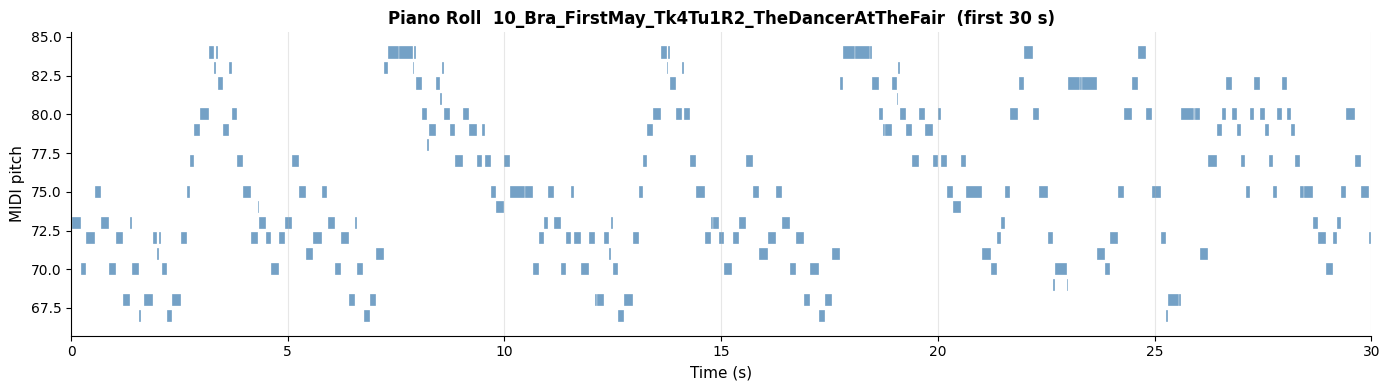

219 notes visible


In [ ]:
import matplotlib.pyplot as plt

def plot_piano_roll(notes, title='', max_sec=30.0):
    fig, ax = plt.subplots(figsize=(14, 4))
    for n in notes:
        if n['onset'] >= max_sec: continue
        dur = min(n['offset'], max_sec) - n['onset']
        ax.barh(n['pitch_midi'], dur, left=n['onset'], height=0.8,
                color='steelblue', alpha=0.75, edgecolor='white', linewidth=0.3)
    ax.set_xlabel('Time (s)', fontsize=11)
    ax.set_ylabel('MIDI pitch', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(0, max_sec)
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

with open(PROCESSED_DIR / processed[0] / 'notes.json') as f:
    sample_notes = json.load(f)
plot_piano_roll(sample_notes, title=f'Piano Roll  {processed[0]}  (first 30 s)')
print(f'{len([n for n in sample_notes if n["onset"] < 30])} notes visible')

---
## 7 · Baseline 1 — pYIN

In [ ]:
import librosa

def voiced_frames_to_notes(f0, voiced, hop_s, min_note_s=0.05):
    notes, in_note, note_start, pitches = [], False, 0, []
    def flush(end):
        if (end - note_start) * hop_s >= min_note_s:
            notes.append({'onset':      note_start * hop_s,
                          'offset':     end * hop_s,
                          'pitch_midi': int(round(np.mean(pitches)))})
    for i, (freq, v) in enumerate(zip(f0, voiced)):
        if v and freq is not None and not np.isnan(freq) and freq > 0:
            midi = 69 + 12 * np.log2(freq / 440.0)
            if not in_note:
                in_note, note_start, pitches = True, i, [midi]
            elif abs(midi - np.mean(pitches)) < 1.0:
                pitches.append(midi)
            else:
                flush(i); note_start, pitches = i, [midi]
        elif in_note:
            flush(i); in_note = False; pitches = []
    if in_note: flush(len(f0))
    return notes

def run_pyin(wav_path):
    y, sr = librosa.load(str(wav_path), sr=RESAMPLE_SR, mono=True)
    hop   = 160   # 10 ms at 16 kHz
    f0, voiced, _ = librosa.pyin(
        y, fmin=librosa.note_to_hz('C2'), fmax=librosa.note_to_hz('C7'),
        sr=sr, hop_length=hop, fill_na=None,
    )
    return voiced_frames_to_notes(f0, voiced, hop / sr)

pyin_dir = PRED_DIR / 'pyin'
for entry in tqdm(dataset_info, desc='pYIN'):
    out = pyin_dir / f'{entry["stem"]}.json'
    if out.exists(): continue
    wav = PROCESSED_DIR / entry['stem'] / 'audio_16k.wav'
    if not wav.exists(): continue
    try:
        notes = run_pyin(wav)
        with open(out, 'w') as f: json.dump(notes, f, indent=2)
    except Exception as e:
        print(f'  [ERROR] {entry["stem"]}: {e}')

print(f'pYIN complete: {len(list(pyin_dir.glob("*.json")))}/{len(dataset_info)} predictions')

pYIN:   0%|          | 0/97 [00:00<?, ?it/s]

pYIN complete: 97/97 predictions


---
## 8 · Baseline 2 — CREPE Notes

In [ ]:
import crepe
from scipy.ndimage import median_filter

from crepe_notes.crepe_notes import run_pitch_tracker, process
from pathlib import Path
import pretty_midi

def run_crepe_notes(wav_path):
    wav_path_obj = Path(wav_path)
    freqs, conf = run_pitch_tracker(str(wav_path_obj), tracker='crepe')

    # HACK: Pass 0.001 to bypass the buggy automatic tuning calculation.
    # This prevents the backing track bleed from shifting the sax out of tune!
    midi_file_path = process(freqs, conf, wav_path_obj, tuning_offset=0.001)

    midi_data = pretty_midi.PrettyMIDI(midi_file_path)
    notes = []
    for instrument in midi_data.instruments:
        for note in instrument.notes:
            notes.append({'onset': note.start, 'offset': note.end, 'pitch_midi': note.pitch})

    return notes

crepe_dir = PRED_DIR / 'crepe_notes'
for entry in tqdm(dataset_info, desc='CREPE Notes'):
    out = crepe_dir / f'{entry["stem"]}.json'
    if out.exists(): continue
    wav = PROCESSED_DIR / entry['stem'] / 'audio_16k.wav'
    if not wav.exists(): continue
    try:
        notes = run_crepe_notes(wav)
        with open(out, 'w') as f: json.dump(notes, f, indent=2)
    except Exception as e:
        print(f'  [ERROR] {entry["stem"]}: {e}')

print(f'CREPE Notes complete: {len(list(crepe_dir.glob("*.json")))}/{len(dataset_info)} predictions')

CREPE Notes:   0%|          | 0/97 [00:00<?, ?it/s]

CREPE Notes complete: 97/97 predictions


---
## 10 · Evaluate Baselines


| Block | Metrics | Tolerances |
|-------|---------|------------|
| Left | Precision / Recall / F-Measure / AOR | onset ±50ms, offset ±50ms or 20%, pitch ±0.5 st |
| Right | P / R / F (onset+pitch only) | onset ±50ms, pitch ±0.5 st, offset ignored |

In [ ]:
import mir_eval
import numpy as np

def notes_to_arrays(notes):
    if not notes:
        return np.zeros((0, 2)), np.zeros(0)
    iv = np.array([[n['onset'], n['offset']] for n in notes], dtype=float)
    p  = np.array([float(n['pitch_midi']) for n in notes], dtype=float)
    return iv, p

def evaluate_piece(ref, est):
    if len(est) == 0:
        return {'P': 0.0, 'R': 0.0, 'F': 0.0, 'AOR': 0.0, 'P_op': 0.0, 'R_op': 0.0, 'F_op': 0.0}

    ref_intervals = np.array([[n['onset'], n['offset']] for n in ref])
    ref_pitches = np.array([mir_eval.util.midi_to_hz(n['pitch_midi']) for n in ref])

    est_intervals = np.array([[n['onset'], n['offset']] for n in est])
    est_pitches = np.array([mir_eval.util.midi_to_hz(n['pitch_midi']) for n in est])

    # --- NEW FIX: Filter out 0-duration notes (ghost notes/frame rounding bugs) ---
    valid_ref = ref_intervals[:, 1] > ref_intervals[:, 0]
    ref_intervals = ref_intervals[valid_ref]
    ref_pitches = ref_pitches[valid_ref]

    valid_est = est_intervals[:, 1] > est_intervals[:, 0]
    est_intervals = est_intervals[valid_est]
    est_pitches = est_pitches[valid_est]

    # If filtering removed everything, return 0
    if len(est_intervals) == 0 or len(ref_intervals) == 0:
        return {'P': 0.0, 'R': 0.0, 'F': 0.0, 'AOR': 0.0, 'P_op': 0.0, 'R_op': 0.0, 'F_op': 0.0}
    # -----------------------------------------------------------------------------

    # --- TRIMMING CODE ---
    first_ref_note = np.min(ref_intervals)
    last_ref_note = np.max(ref_intervals)

    valid_idxs = np.unique(np.where((est_intervals >= first_ref_note) & (est_intervals <= last_ref_note))[0])
    est_intervals = est_intervals[valid_idxs]
    est_pitches = est_pitches[valid_idxs]

    if len(est_intervals) == 0:
        return {'P': 0.0, 'R': 0.0, 'F': 0.0, 'AOR': 0.0, 'P_op': 0.0, 'R_op': 0.0, 'F_op': 0.0}

    # 1. Strict Metrics (with offsets)
    P, R, F, AOR = mir_eval.transcription.precision_recall_f1_overlap(
        ref_intervals, ref_pitches, est_intervals, est_pitches,
        onset_tolerance=0.05, pitch_tolerance=50.0,
        offset_ratio=0.2, offset_min_tolerance=0.05
    )

    # 2. Lenient Metrics (NO OFFSETS)
    P_op, R_op, F_op, _ = mir_eval.transcription.precision_recall_f1_overlap(
        ref_intervals, ref_pitches, est_intervals, est_pitches,
        onset_tolerance=0.05, pitch_tolerance=50.0,
        offset_ratio=None
    )

    return {'P': P, 'R': R, 'F': F, 'AOR': AOR, 'P_op': P_op, 'R_op': R_op, 'F_op': F_op}

def evaluate_model(pred_dir, model_name):
    results = []
    for entry in dataset_info:
        stem     = entry['stem']
        ref_path = PROCESSED_DIR / stem / 'notes.json'
        est_path = pred_dir / f'{stem}.json'
        if not ref_path.exists() or not est_path.exists(): continue
        with open(ref_path) as f: ref = json.load(f)
        with open(est_path) as f: est = json.load(f)
        m = evaluate_piece(ref, est)
        m['stem'] = stem
        results.append(m)
    keys = ['P', 'R', 'F', 'AOR', 'P_op', 'R_op', 'F_op']
    avg  = {k: float(np.mean([r[k] for r in results])) for k in keys}
    avg['n_pieces'] = len(results)
    return {'model': model_name, 'aggregate': avg, 'per_piece': results}

print('Evaluating pYIN ...')
pyin_results  = evaluate_model(pyin_dir,  'pYIN')
print('Evaluating CREPE Notes ...')
crepe_results = evaluate_model(crepe_dir, 'CREPE Notes')
print('Evaluating MT3 ...')
#mt3_results   = evaluate_model(mt3_dir,   'MT3')

all_results = [pyin_results, crepe_results]#, mt3_results]
with open(EVAL_DIR / 'results.json', 'w') as f:
    json.dump(all_results, f, indent=2)

print()
hdr = f"  {'Model':<16} {'P':>6} {'R':>6} {'F1':>6} {'AOR':>6}   {'P(op)':>6} {'R(op)':>6} {'F1(op)':>7}"
print('=' * len(hdr))
print(hdr)
print(f"  {'':16} {'':6} {'':6} {'':6} {'':6}   {'<-- onset+pitch only':>21}")
print('=' * len(hdr))
for r in all_results:
    ag = r['aggregate']
    print(f"  {r['model']:<16} {ag['P']:>6.3f} {ag['R']:>6.3f} {ag['F']:>6.3f} "
          f"{ag['AOR']:>6.3f}   {ag['P_op']:>6.3f} {ag['R_op']:>6.3f} {ag['F_op']:>7.3f}")
print('=' * len(hdr))
print(f'  Left: onset+offset+pitch  |  Tolerances: onset +/-{ONSET_TOL*1000:.0f}ms, '
      f'offset +/-{OFFSET_MIN*1000:.0f}ms or {OFFSET_RATIO*100:.0f}%, pitch +/-{PITCH_TOL} st')

Evaluating pYIN ...
Evaluating CREPE Notes ...
Evaluating MT3 ...

  Model                 P      R     F1    AOR    P(op)  R(op)  F1(op)
                                                  <-- onset+pitch only
  pYIN              0.484  0.317  0.382  0.749    0.648  0.422   0.510
  CREPE Notes       0.752  0.599  0.666  0.799    0.834  0.665   0.739
  Left: onset+offset+pitch  |  Tolerances: onset +/-50ms, offset +/-50ms or 20%, pitch +/-0.5 st


---
## 11 · Plot Results

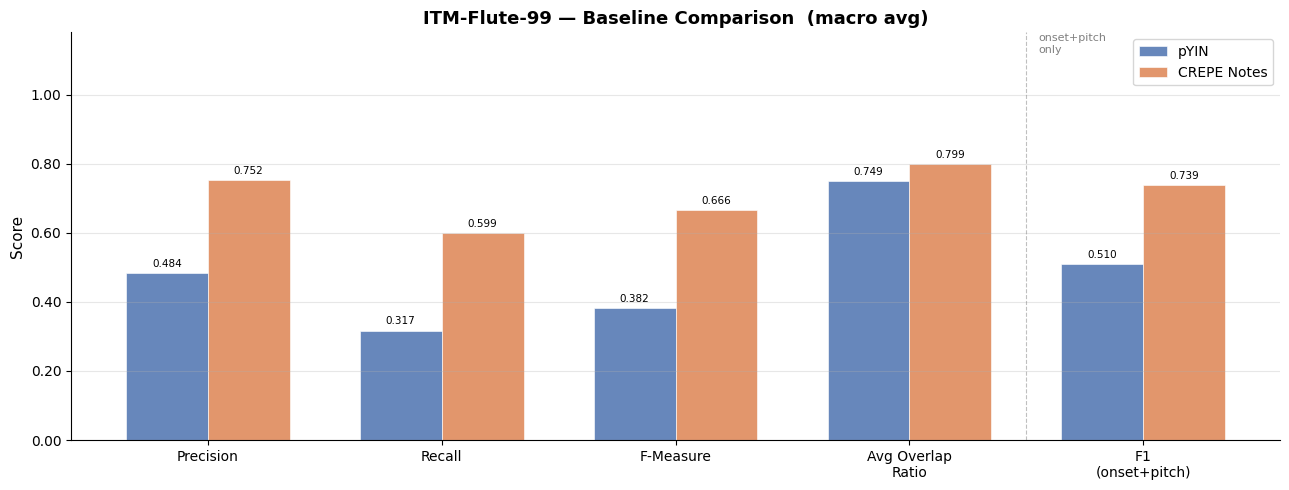

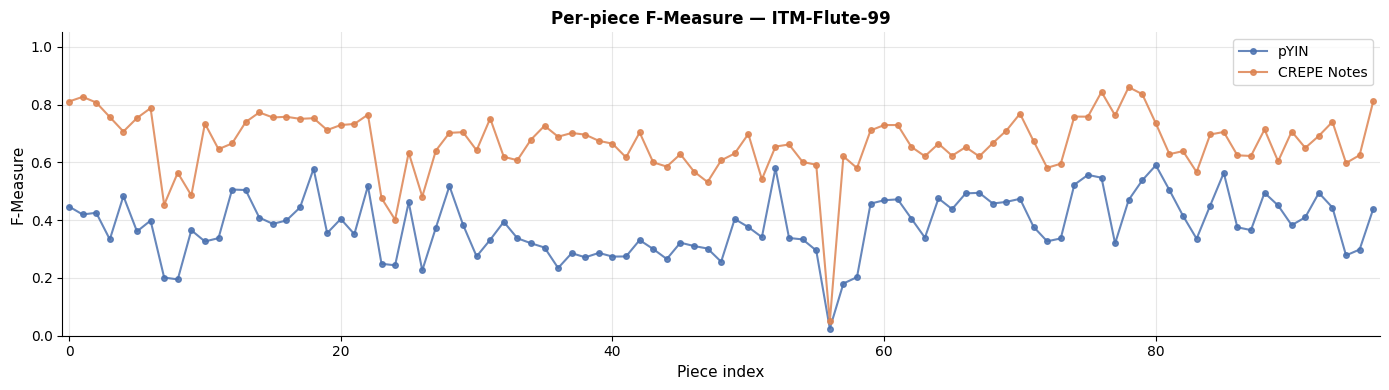

Figures saved to /content/crepe_yolo/evaluation


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

COLORS = ['#4C72B0', '#DD8452', '#55A868']   # pYIN, CREPE Notes, MT3

# ── Grouped bar chart: all aggregate metrics ──────────────────────────────────
metrics       = ['P',         'R',      'F',           'AOR',               'F_op']
metric_labels = ['Precision', 'Recall', 'F-Measure',   'Avg Overlap\nRatio', 'F1\n(onset+pitch)']
n_models      = len(all_results)
x             = np.arange(len(metrics))
bar_w         = 0.7 / n_models

fig, ax = plt.subplots(figsize=(13, 5))
for i, (res, color) in enumerate(zip(all_results, COLORS)):
    offset = (i - n_models / 2 + 0.5) * bar_w
    vals   = [res['aggregate'][m] for m in metrics]
    bars   = ax.bar(x + offset, vals, bar_w, label=res['model'],
                    color=color, alpha=0.85, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=10)
ax.set_ylim(0, 1.18)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('ITM-Flute-99 — Baseline Comparison  (macro avg)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# Dashed divider between onset+offset block and onset-only block
ax.axvline(x=3.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
ax.text(3.55, 1.12, 'onset+pitch\nonly', fontsize=8, color='grey')
plt.tight_layout()
plt.savefig(EVAL_DIR / 'baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Per-piece F1 line plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
stems = [r['stem'] for r in all_results[0]['per_piece']]
x_pos = np.arange(len(stems))

for res, color in zip(all_results, COLORS):
    by_stem  = {r['stem']: r['F'] for r in res['per_piece']}
    f_scores = [by_stem.get(s, 0.0) for s in stems]
    ax.plot(x_pos, f_scores, 'o-', label=res['model'],
            color=color, alpha=0.85, markersize=4, linewidth=1.5)

ax.set_xlabel('Piece index', fontsize=11)
ax.set_ylabel('F-Measure', fontsize=11)
ax.set_title('Per-piece F-Measure — ITM-Flute-99', fontsize=12, fontweight='bold')
ax.set_xlim(-0.5, len(stems) - 0.5)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(EVAL_DIR / 'per_piece_f1.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Figures saved to {EVAL_DIR}')

---
## 12 · Save All Outputs to Google Drive

In [ ]:
import shutil

DRIVE_OUT = Path('/content/drive/MyDrive/DL Project/crepe_yolo_outputs')
DRIVE_OUT.mkdir(parents=True, exist_ok=True)

shutil.copytree(SPLIT_DIR, DRIVE_OUT / 'configs',     dirs_exist_ok=True)
shutil.copytree(EVAL_DIR,  DRIVE_OUT / 'evaluation',  dirs_exist_ok=True)
shutil.copytree(PRED_DIR,  DRIVE_OUT / 'predictions', dirs_exist_ok=True)

# Copy cleaned notes.json only (skip large audio_16k.wav)
proc_out = DRIVE_OUT / 'processed'
for p in PROCESSED_DIR.rglob('notes.json'):
    dst = proc_out / p.relative_to(PROCESSED_DIR)
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(p, dst)

print(f'Saved to Google Drive: {DRIVE_OUT}')
print('Contents:')
for item in sorted(DRIVE_OUT.iterdir()):
    n_files = len(list(item.rglob('*'))) if item.is_dir() else 1
    print(f'  {item.name}/  ({n_files} files)')
print()
print('  processed/   -> cleaned notes.json per piece')
print('  predictions/ -> baseline prediction JSONs (for evaluation comparison)')
print('  evaluation/  -> results.json + figures')


Saved to Google Drive: /content/drive/MyDrive/DL Project/crepe_yolo_outputs
Contents:
  configs/  (1 files)
  evaluation/  (5 files)
  predictions/  (197 files)
  processed/  (915 files)

  processed/   -> cleaned notes.json per piece
  predictions/ -> baseline prediction JSONs (for evaluation comparison)
  evaluation/  -> results.json + figures


# 13. Filosax

In [ ]:
import urllib.request
import zipfile
import os
import json
import shutil
from pathlib import Path
from tqdm.auto import tqdm

# Path where processed data lives permanently
DRIVE_OUT_FILO = Path('/content/drive/MyDrive/DL Project/crepe_yolo_outputs/processed/filosax')
DRIVE_OUT_FILO.mkdir(parents=True, exist_ok=True)

# 1. SMART CHECK: Does the data already exist in Drive?
existing_stems = [d.name for d in DRIVE_OUT_FILO.iterdir() if d.is_dir()]

if len(existing_stems) > 0:
    print(f"Dataset already found in Drive! Skipping download.")
    print(f"Instantly restored {len(existing_stems)} stems to memory.")
    # Restore the variable instantly so later cells don't break
    filosax_stems = existing_stems

else:
    # 2. HEAVY LIFTING: Only runs if Drive folder is empty
    print("Drive folder is empty. Downloading and processing Filosax...")

    dropbox_url = "https://www.dropbox.com/scl/fo/tbw5sc0ie5pcxyufsatah/AImpbNJbAwNAdZerfXPM4tc?rlkey=a8yozymjaq3spiroi1tj7zt7r&dl=1"
    local_zip = "/content/filosax.zip"
    raw_dir = Path("/content/filosax_raw")

    print("Downloading Filosax to Colab Temp Storage...")
    if not os.path.exists(local_zip):
        urllib.request.urlretrieve(dropbox_url, local_zip)

    print("Extracting ONLY Sax.wav and annotations.json files...")
    os.makedirs(raw_dir, exist_ok=True)
    with zipfile.ZipFile(local_zip, 'r') as zip_ref:
        target_files = [f for f in zip_ref.namelist() if f.endswith('Sax.wav') or f.endswith('annotations.json')]
        zip_ref.extractall(raw_dir, members=target_files)

    print("Processing and cleaning files...")
    filosax_stems = []

    for p_dir in raw_dir.rglob('Participant*'):
        if not p_dir.is_dir(): continue
        p_id = p_dir.name.split()[-1]

        for take_dir in p_dir.iterdir():
            if not take_dir.is_dir(): continue

            wav_path = take_dir / "Sax.wav"
            json_path = take_dir / "annotations.json"

            if not wav_path.exists() or not json_path.exists(): continue

            stem = f"filo_p{p_id}_{take_dir.name}"
            filosax_stems.append(stem)

            stem_out_dir = DRIVE_OUT_FILO / stem
            stem_out_dir.mkdir(exist_ok=True, parents=True)

            dest_annot = stem_out_dir / 'notes.json'
            if not dest_annot.exists():
                with open(json_path, 'r') as f:
                    raw_json = json.load(f)

                filo_notes = []
                for note in raw_json.get('notes', []):
                    filo_notes.append({
                        'onset': note['a_start_time'],
                        'offset': note['a_end_time'],
                        'pitch_midi': note['midi_pitch']
                    })
                with open(dest_annot, 'w') as f:
                    json.dump(filo_notes, f, indent=2)

            out_wav = stem_out_dir / 'audio_16k.wav'
            if not out_wav.exists():
                resample_normalize(wav_path, out_wav)

    print("Cleaning up massive raw files to free up space...")
    os.remove(local_zip)
    shutil.rmtree(raw_dir)
    print(f"Done! {len(filosax_stems)} tracks saved to Drive.")

Dataset already found in Drive! Skipping download.
Instantly restored 240 stems to memory.


In [ ]:
import random
import json
from pathlib import Path

# Shuffle deterministically
file_stems = sorted(filosax_stems)
random.seed(42)
random.shuffle(file_stems)

n_files = len(file_stems)
train_idx = int(n_files * 0.64)
val_idx = int(n_files * 0.80)

filosax_splits = {
    "dataset": "Filosax",
    "train": file_stems[:train_idx],
    "val": file_stems[train_idx:val_idx],
    "test": file_stems[val_idx:]
}

# Save split to your existing configs directory
SPLIT_DIR = Path('/content/crepe_yolo/configs')
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

split_path = SPLIT_DIR / 'filosax_splits.json'
with open(split_path, 'w') as f:
    json.dump(filosax_splits, f, indent=2)

print(f"Split saved: {len(filosax_splits['train'])} Train | {len(filosax_splits['val'])} Val | {len(filosax_splits['test'])} Test")

Split saved: 153 Train | 39 Val | 48 Test


In [ ]:
PRED_DIR_FILO = Path('/content/crepe_yolo/predictions/filosax')
pyin_dir_filo = PRED_DIR_FILO / 'pyin'
crepe_dir_filo = PRED_DIR_FILO / 'crepe_notes'
pyin_dir_filo.mkdir(parents=True, exist_ok=True)
crepe_dir_filo.mkdir(parents=True, exist_ok=True)

# Generate predictions ONLY for the Test set
for stem in tqdm(filosax_splits["test"], desc='Running Baselines on Test Set'):
    processed_wav = DRIVE_OUT_FILO / stem / 'audio_16k.wav'
    if not processed_wav.exists(): continue

    # pYIN
    pyin_out = pyin_dir_filo / f'{stem}.json'
    if not pyin_out.exists():
        notes = run_pyin(processed_wav)
        with open(pyin_out, 'w') as f: json.dump(notes, f, indent=2)

    # CREPE Notes
    crepe_out = crepe_dir_filo / f'{stem}.json'
    if not crepe_out.exists():
        notes = run_crepe_notes(processed_wav)
        with open(crepe_out, 'w') as f: json.dump(notes, f, indent=2)

Running Baselines on Test Set:   0%|          | 0/48 [00:00<?, ?it/s]


CREPE inference: 00:00

1203/1203 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step



CREPE inference: 00:34


/content/drive/MyDrive/DL Project/crepe_yolo_outputs/processed/filosax/filo_p5_30/audio_16k.wav
Onsets file not found at /content/drive/MyDrive/DL Project/crepe_yolo_outputs/processed/filosax/filo_p5_30/audio_16k.onsets.npz
Running onset detection...


...

/content/drive/MyDrive/DL Project/crepe_yolo_outputs/processed/filosax/filo_p1_29/audio_16k.wav
Onsets file not found at /content/drive/MyDrive/DL Project/crepe_yolo_outputs/processed/filosax/filo_p1_29/audio_16k.onsets.npz
Running onset detection...



CREPE inference: 00:00

1318/1318 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step



CREPE inference: 00:26


/content/drive/MyDrive/DL Project/crepe_yolo_outputs/processed/filosax/filo_p4_20/audio_16k.wav
Onsets file not found at /content/drive/MyDrive/DL Project/crepe_yolo_outputs/processed/filosax/filo_p4_20/audio_16k.onsets.npz
Running onset detection...


In [ ]:
import matplotlib.ticker as mtick
import numpy as np
import json
from pathlib import Path

# Match the ITM-Flute "evaluation" directory naming, but save directly to Drive
DRIVE_EVAL_DIR = Path('/content/drive/MyDrive/DL Project/crepe_yolo_outputs/evaluation')
DRIVE_EVAL_DIR.mkdir(parents=True, exist_ok=True)

def evaluate_model_filosax(pred_dir, model_name, test_stems):
    results = []
    for stem in test_stems:
        # Ground truth from Drive
        ref_path = DRIVE_OUT_FILO / stem / 'notes.json'
        # Predictions from Cell C
        est_path = pred_dir / f'{stem}.json'

        if not ref_path.exists() or not est_path.exists():
            continue

        with open(ref_path) as f: ref = json.load(f)
        with open(est_path) as f: est = json.load(f)

        m = evaluate_piece(ref, est)
        m['stem'] = stem
        results.append(m)

    keys = ['P', 'R', 'F', 'AOR', 'P_op', 'R_op', 'F_op']
    if len(results) == 0: return None
    avg  = {k: float(np.mean([r[k] for r in results])) for k in keys}
    avg['n_pieces'] = len(results)
    return {'model': model_name, 'aggregate': avg, 'per_piece': results}

print('Evaluating pYIN...')
pyin_results_filo  = evaluate_model_filosax(pyin_dir_filo, 'pYIN', filosax_splits["test"])

print('Evaluating CREPE Notes...')
crepe_results_filo = evaluate_model_filosax(crepe_dir_filo, 'CREPE Notes', filosax_splits["test"])

all_results_filo = [r for r in [pyin_results_filo, crepe_results_filo] if r is not None]

# Save with a consistent name
results_file = DRIVE_EVAL_DIR / 'filosax_results.json'
with open(results_file, 'w') as f:
    json.dump(all_results_filo, f, indent=2)

print(f"Numerical results saved to {results_file}")

Evaluating pYIN...
Evaluating CREPE Notes...
Numerical results saved to /content/drive/MyDrive/DL Project/crepe_yolo_outputs/evaluation/filosax_results.json


Plot saved successfully to /content/drive/MyDrive/DL Project/crepe_yolo_outputs/evaluation/filosax_baseline_comparison.png


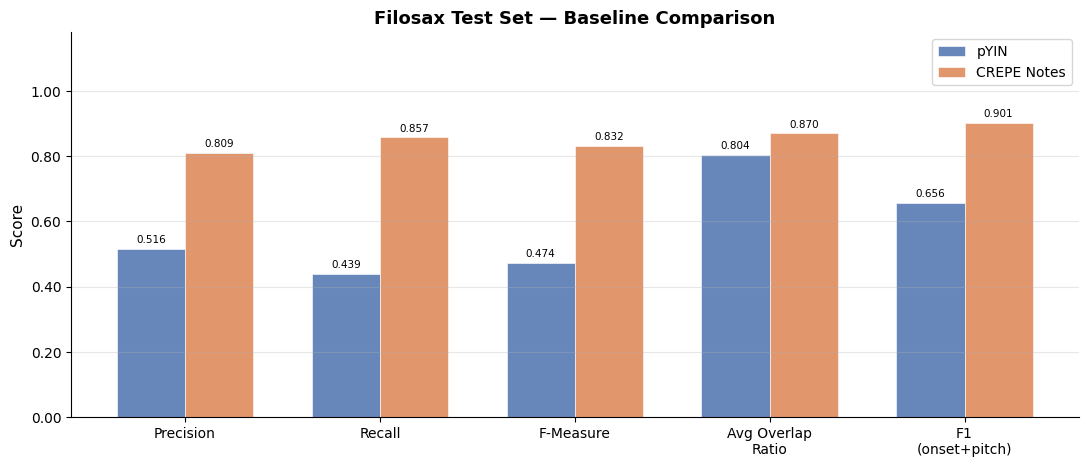

In [ ]:
import matplotlib.pyplot as plt

COLORS = ['#4C72B0', '#DD8452']
metrics = ['P', 'R', 'F', 'AOR', 'F_op']
metric_labels = ['Precision', 'Recall', 'F-Measure', 'Avg Overlap\nRatio', 'F1\n(onset+pitch)']

if all_results_filo:
    n_models = len(all_results_filo)
    x = np.arange(len(metrics))
    bar_w = 0.7 / n_models

    fig, ax = plt.subplots(figsize=(13, 5))
    for i, (res, color) in enumerate(zip(all_results_filo, COLORS)):
        offset = (i - n_models / 2 + 0.5) * bar_w
        vals = [res['aggregate'][m] for m in metrics]
        bars = ax.bar(x + offset, vals, bar_w, label=res['model'], color=color, alpha=0.85, edgecolor='white', linewidth=0.5)

        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012, f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)

    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels, fontsize=10)
    ax.set_ylim(0, 1.18)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title('Filosax Test Set — Baseline Comparison', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10, loc='upper right')
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Save plot matching the ITM-Flute naming convention
    plot_file = DRIVE_EVAL_DIR / 'filosax_baseline_comparison.png'
    plt.savefig(plot_file, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"Plot saved successfully to {plot_file}")

    plt.show()
else:
    print("No evaluation results to plot. Make sure Cell C finished running.")